<a href="https://colab.research.google.com/github/caffeinated-beverage/NikkiSingh_DTSC3020_Fall2025/blob/main/Assignment_3_Association_Rule_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [68]:
# write your answer here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

df = pd.read_csv("bread_basket.csv")

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [69]:
# write your answer here
print(df.dtypes)

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [70]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

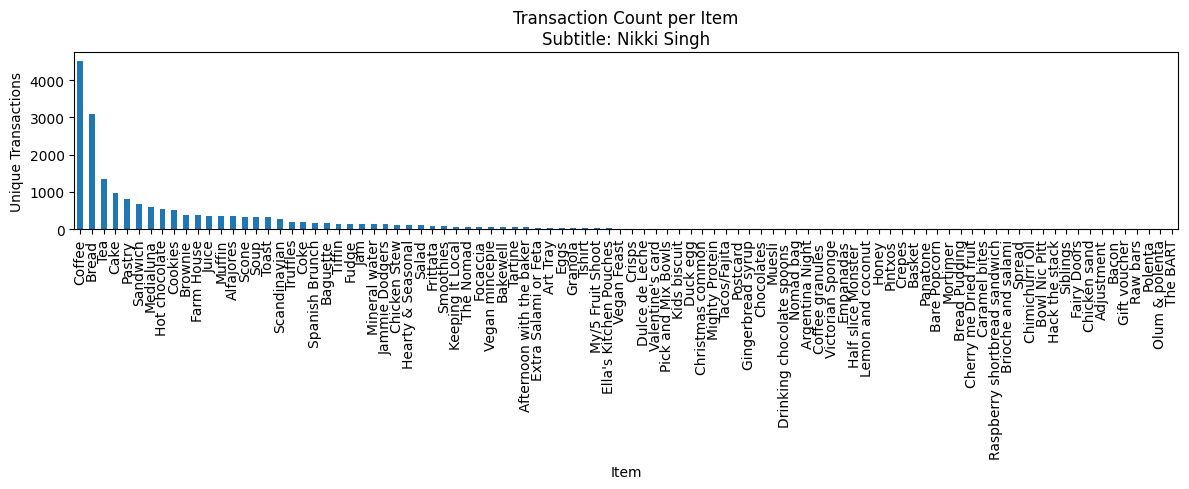

In [71]:
# c) Bar plot of transaction counts per item
subtitle = "Nikki Singh"
item_counts =  (df.groupby('item')['transaction']
                .nunique()
                .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [72]:
# write your answer here
target_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

reported_counts = item_counts.reindex(target_items)

print(reported_counts.reset_index(name='unique_transactions'))

           item  unique_transactions
0        Coffee                 4528
1           Tea                 1350
2     Alfajores                  344
3         Juice                  365
4  Chicken Stew                  123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [73]:
# write your answer here
basket = (df.groupby('transaction')['item'].apply(list).tolist())

te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
oht = pd.DataFrame(te_ary, columns = te.columns_).astype(bool)

freq_itemsets = fpgrowth(oht, min_support=0.02, use_colnames=True)
freq_itemsets = freq_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"Total Frequent Itemsets: {len(freq_itemsets)}")
freq_itemsets.head(15)

Total Frequent Itemsets: 33


,support,itemsets
0,0.478394,(Coffee)
1,0.327205,(Bread)
2,0.142631,(Tea)
3,0.103856,(Cake)
4,0.090016,"(Bread, Coffee)"
5,0.086107,(Pastry)
6,0.071844,(Sandwich)
7,0.061807,(Medialuna)
8,0.058320,(Hot chocolate)
9,0.054728,"(Cake, Coffee)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [74]:
# write your answer here
rules = association_rules(freq_itemsets, metric = 'confidence', min_threshold=0.15)

report_table = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('confidence', ascending=False)
report_table.head(15)

,antecedents,consequents,support,confidence,lift
13,(Toast),(Coffee),0.023666,0.704403,1.472431
6,(Medialuna),(Coffee),0.035182,0.569231,1.189878
4,(Pastry),(Coffee),0.047544,0.552147,1.154168
15,(Juice),(Coffee),0.020602,0.534247,1.116750
5,(Sandwich),(Coffee),0.038246,0.532353,1.112792
2,(Cake),(Coffee),0.054728,0.526958,1.101515
9,(Cookies),(Coffee),0.028209,0.518447,1.083723
7,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311
3,(Tea),(Coffee),0.049868,0.349630,0.730840
8,(Pastry),(Bread),0.029160,0.338650,1.034977


## 5) Rule Subgraph (5 pts)
Plot a subgraph for specific items (Bread, Coffee, Cake, Tea)

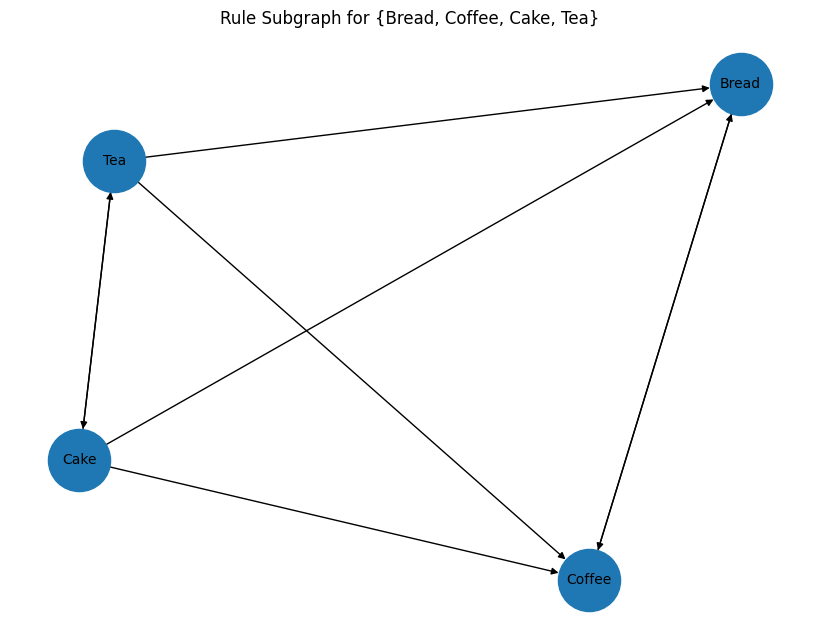

In [75]:
focus = {'Bread', 'Coffee', 'Cake', 'Tea'}
sub_rules = rules[rules['antecedents'].apply(lambda s: s.issubset(focus)) &
                  rules['consequents'].apply(lambda s: s.issubset(focus))]

G = nx.DiGraph()
for _, r in sub_rules.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    c = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, c, weight=r['confidence'])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10, arrows=True)
plt.title("Rule Subgraph for {Bread, Coffee, Cake, Tea}")
plt.show()

## 6) Interpretation (5 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*
- **Support:** Exactly 1.00% (0.0100) of all transactions in the dataset contain Coffee, Cake and Bread together.
- **Confidence:** When a customer already has Coffee and Cake in their basket, there is a 18.34% (0.1834) chance they will also buy bread.
- **Lift:** The lift is 0.56 (rounded). Since it is significantly less than 1, this implies negative association. This means customers buying Coffee and Cake are statistically less likely to purchase Bread than the average customer. These buyers could be focusing instead on sweet pairings and cafe drinks instead of purchasing typical bakery staple foods.